# Proyek Riset Eksplorasi Data: Persona & Gaya Hidup Mahasiswa
**Disusun oleh:** Rayhan Christian Wewengkang (2024081005) & Azzah Muthia (2024011014)

**Fokus Analisis:** Pemetaan Profil Nyata Mahasiswa Era Digital 
**Algoritma Pembanding:** K-Means Clustering vs K-Medoids Clustering

Notebook ini dirancang untuk memetakan karakter dan kebiasaan mahasiswa berdasarkan 3 pilar: Pola Digital, Siklus Biologis, dan Indikator Psikologis.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, pairwise_distances

## 1. Data & Preprocessing


In [8]:
file_path = "Survei Pola Digital & Kehidupan Mahasiswa (Penelitian Machine Learning) (Responses) - Form Responses 1-2.csv"
df = pd.read_csv(file_path)

## 2. CLEANING & RE-MAPPING KE SKALA ORDINAL (1 = Paling Sehat, 4/5 = Paling Berisiko)


In [ ]:
column_mapping = {
    df.columns[0]: 'timestamp', df.columns[1]: 'nama', df.columns[2]: 'universitas',
    df.columns[3]: 'screen_time_hp_raw', df.columns[4]: 'screen_time_laptop_raw',
    df.columns[5]: 'aktivitas_dominan', df.columns[6]: 'refleks_cek_hp',
    df.columns[7]: 'durasi_tidur_raw', df.columns[8]: 'lelah_pagi',
    df.columns[9]: 'jeda_layar_tidur_raw', df.columns[10]: 'sulit_rileks',
    df.columns[11]: 'cemas_fomo', df.columns[12]: 'lelah_mental'
}
df_clean = df.rename(columns=column_mapping)

# SOLUSI: Menambahkan '< 3 jam': 1 agar responden dengan screen time HP rendah tidak menjadi NaN
map_hp = {'< 3 jam': 1, '3 - 6 jam': 2, '6 - 9 jam': 3, '9 jam': 4}

map_laptop = {'< 3 jam': 1, '3 - 6 jam': 2, '6 - 9 jam': 3, '9 jam': 4}
map_tidur = {
    '7 - 8 jam (Cukup / Normal)': 1,
    '5 - 6 jam (Kurang)': 2,
    '9 jam (Berlebih)': 3,
    '< 5 jam (Sangat kurang / Insomnia)': 4
}
map_jeda = {
    '60 menit (Ada jeda yang cukup panjang)': 1,
    '30 - 60 menit': 2,
    '15 - 30 menit': 3,
    '< 15 Menit (Main HP sampai tertidur)': 4
}

df_clean['screen_time_hp'] = df_clean['screen_time_hp_raw'].map(map_hp)
df_clean['screen_time_laptop'] = df_clean['screen_time_laptop_raw'].map(map_laptop)
df_clean['durasi_tidur'] = df_clean['durasi_tidur_raw'].map(map_tidur)
df_clean['jeda_layar_tidur'] = df_clean['jeda_layar_tidur_raw'].map(map_jeda)

# Verifikasi Opsional: Memastikan tidak ada lagi NaN di kolom pilar utama
print("Jumlah NaN setelah perbaikan:")
print(df_clean[['screen_time_hp', 'screen_time_laptop', 'durasi_tidur', 'jeda_layar_tidur']].isnull().sum())

Jumlah NaN setelah perbaikan:
screen_time_hp        0
screen_time_laptop    0
durasi_tidur          0
jeda_layar_tidur      0
dtype: int64


## 3. FITUR SELEKSI

In [10]:
features = [
    'screen_time_hp', 'screen_time_laptop', 'refleks_cek_hp', 
    'durasi_tidur', 'lelah_pagi', 'jeda_layar_tidur', 
    'sulit_rileks', 'cemas_fomo', 'lelah_mental'
]

X = df_clean[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 4. IMPLEMENTASI ALGORITMA 1 : K-MEANS


In [11]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_clean['kmeans_cluster'] = kmeans.fit_predict(X_scaled)
kmeans_sil = silhouette_score(X_scaled, df_clean['kmeans_cluster'])

## 5. IMPLEMENTASI ALGORITMA 2: K-MEDOIDS (Robust PAM)

In [12]:
def run_kmedoids(X, n_clusters, max_iter=300, random_state=42):
    np.random.seed(random_state)
    n_samples = X.shape[0]
    medoids = np.random.choice(n_samples, n_clusters, replace=False)
    D = pairwise_distances(X, metric='euclidean')
    labels = np.argmin(D[:, medoids], axis=1)
    
    for _ in range(max_iter):
        old_medoids = medoids.copy()
        for k in range(n_clusters):
            members = np.where(labels == k)[0]
            if len(members) == 0: continue
            sub_D = D[members[:, None], members]
            medoids[k] = members[np.argmin(np.sum(sub_D, axis=1))]
        labels = np.argmin(D[:, medoids], axis=1)
        if np.array_equal(old_medoids, medoids): break
    return medoids, labels

medoid_indices, kmedoids_labels = run_kmedoids(X_scaled, n_clusters=3, random_state=42)
df_clean['kmedoids_cluster'] = kmedoids_labels
kmedoids_sil = silhouette_score(X_scaled, kmedoids_labels)

# Cetak Metrik Evaluasi
print("=========================================================")
print(f"📊 METRIK EVALUASI SILHOUETTE SCORE (K=3):")
print(f"-> K-Means Clustering   : {kmeans_sil:.4f}")
print(f"-> K-Medoids Clustering : {kmedoids_sil:.4f}")
print("=========================================================\n")

📊 METRIK EVALUASI SILHOUETTE SCORE (K=3):
-> K-Means Clustering   : 0.1403
-> K-Medoids Clustering : 0.1170



## 6. Visualisasi Komparatif Heatmap Profil Klaster

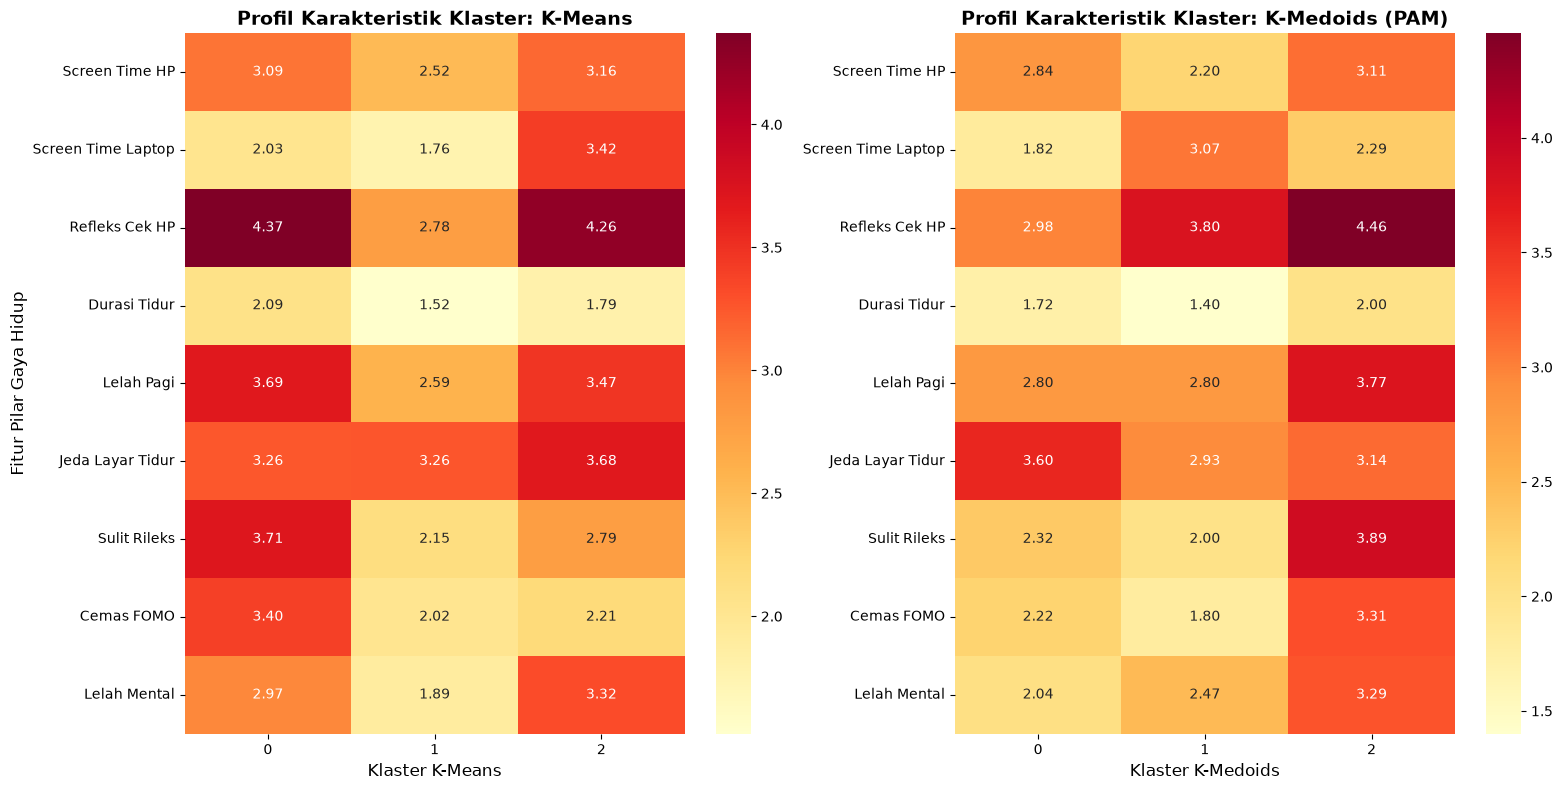

In [13]:
feature_labels = [
    'Screen Time HP', 'Screen Time Laptop', 'Refleks Cek HP',
    'Durasi Tidur', 'Lelah Pagi', 'Jeda Layar Tidur',
    'Sulit Rileks', 'Cemas FOMO', 'Lelah Mental'
]

# Siapkan dataframe profil karakteristik (agregat nilai mean)
kmeans_profile = df_clean.groupby('kmeans_cluster')[features].mean().T
kmeans_profile.index = feature_labels

kmedoids_profile = df_clean.groupby('kmedoids_cluster')[features].mean().T
kmedoids_profile.index = feature_labels

# Membuat Subplots 1 Baris 2 Kolom agar tampil berdampingan
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Heatmap K-Means (Kiri)
sns.heatmap(kmeans_profile, annot=True, cmap='YlOrRd', fmt=".2f", cbar=True, ax=axes[0])
axes[0].set_title('Profil Karakteristik Klaster: K-Means', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Klaster K-Means', fontsize=12)
axes[0].set_ylabel('Fitur Pilar Gaya Hidup', fontsize=12)

# Heatmap K-Medoids (Kanan)
sns.heatmap(kmedoids_profile, annot=True, cmap='YlOrRd', fmt=".2f", cbar=True, ax=axes[1])
axes[1].set_title('Profil Karakteristik Klaster: K-Medoids (PAM)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Klaster K-Medoids', fontsize=12)
axes[1].set_ylabel('', fontsize=12) 

plt.tight_layout()
plt.show() 



In [14]:
def cek_profil_mahasiswa(nama_dicari):
    # Menggunakan variabel global df_clean agar tidak ketergantungan file .csv eksternal
    global df_clean
    
    # Proteksi jika variabel utama belum di-run
    if 'df_clean' not in globals():
        print("❌ Eror: Struktur data utama 'df_clean' belum terbentuk di memori.")
        print("💡 Solusi: Silakan jalankan (Run) kembali cell utama pemodelan di atas terlebih dahulu.")
        return
        
    # Pembersihan nama dari spasi berlebih dan konversi ke huruf kecil
    df_clean['nama_clean'] = df_clean['nama'].astype(str).str.strip().str.lower()
    
    # Pembersihan input pencarian
    query = str(nama_dicari).strip().lower()
    
    # Eksekusi pencarian berbasis kecocokan sebagian kata
    target = df_clean[df_clean['nama_clean'].str.contains(query, na=False, regex=False)]
    
    # Penanganan jika data tidak ditemukan
    if target.empty:
        print(f"❌ Responden dengan nama '{nama_dicari}' tidak ditemukan dalam dataset.")
        print("-" * 70)
        print("💡 Rekomendasi Solusi:")
        print("   1. Coba masukkan 1 kata kunci saja (Contoh: 'Deryl' atau 'Arifin').")
        print("   2. Berikut adalah beberapa contoh nama responden Anda yang valid:")
        contoh_nama = df_clean['nama'].head(5).values
        for nama_contoh in contoh_nama:
            print(f"      - {nama_contoh}")
        print("=" * 70)
        return

    # Kamus Penjelasan Karakteristik Klaster K-Medoids (Persona Akademik)
    kamus_persona = {
        0: {
            "label": "🔴 THE DIGITAL BURNOUT & EXHAUSTED (Krisis Biologis & Psikologis)",
            "deskripsi": "Kelompok kritis yang mengalami gangguan keseimbangan ekstrem. Kualitas tidur mereka\n"
                         "hancur akibat stimulasi layar ponsel hingga detik-detik terakhir sebelum tidur. Menunjukkan\n"
                         "gejala kelelahan fisik di pagi hari dan ketidakmampuan untuk mengistirahatkan pikiran (overthinking).",
            "rekomendasi": "Wajib menerapkan digital detox dan pembatasan screen time ketat minimal 1 jam sebelum tidur."
        },
        1: {
            "label": "🟢 THE BALANCED STUDENT (Mahasiswa Stabil & Terkontrol)",
            "deskripsi": "Kelompok mahasiswa ideal yang berhasil menjaga batasan konsumsi digital di tengah tuntutan kuliah.\n"
                         "Tingkat kecemasan, FOMO, dan kelelahan mental berada di titik paling rendah karena mereka\n"
                         "memiliki jeda layar yang sehat sebelum tidur dan durasi tidur biologis yang normal.",
            "rekomendasi": "Pertahankan pola ini dan jadilah peer-support bagi rekan klaster lain."
        },
        2: {
            "label": "🟡 THE SOCIALLY HYPERACTIVE / FOMO DRIVEN (Kecanduan Sosmed / At-Risk Group)",
            "deskripsi": "Kelompok mahasiswa yang didorong oleh kecemasan sosial akut akan tertinggalnya informasi (FOMO).\n"
                         "Refleks mengecek ponsel sangat tinggi. Mereka berada di fase awal risiko (at-risk) menuju burnout,\n"
                         "meski energi mental mereka saat ini masih mampu mengompensasi kelelahan tersebut.",
            "rekomendasi": "Kurangi refleks mengecek notifikasi dengan mematikan pemberitahuan non-esensial."
        }
    }
    
    # Tampilkan kartu profil jika target ditemukan
    for idx, row in target.iterrows():
        cluster_id = int(row['kmedoids_cluster'])
        persona = kamus_persona[cluster_id]
        
        print("="*70)
        print(f"👤 PROFIL RESPONDEN")
        print("="*70)
        print(f" Nama Responden   : {row['nama']}")
        print(f" Universitas      : {row['universitas']}")
        print(f" Aktivitas Layar  : {row['aktivitas_dominan']}\n")
        
        print(f" STATUS KLASTER (K-MEDOIDS):")
        print(f"-> {persona['label']}\n")
        
        print(f" ANALISIS PERILAKU & GAYA HIDUP:")
        print(persona['deskripsi'])
        
        print(f"\n💡 REKOMENDASI INTERVENSI:")
        print(persona['rekomendasi'])
        
        print("-" * 70)
        print(f" NILAI INDIKATOR UTAMA (Skala 1-5 / 1-4):")
        print(f"   [Pilar Digital]    Screen Time HP: {row['screen_time_hp']} | Refleks Cek HP: {row['refleks_cek_hp']}")
        print(f"   [Pilar Biologis]   Durasi Tidur  : {row['durasi_tidur']} | Lelah di Pagi  : {row['lelah_pagi']}")
        print(f"   [Pilar Psikologis] Sulit Rileks   : {row['sulit_rileks']} | Skor Cemas FOMO: {row['cemas_fomo']}")
        print("="*70 + "\n")

In [18]:
cek_profil_mahasiswa("Go Younjung")

👤 PROFIL RESPONDEN
 Nama Responden   : Go Younjung
 Universitas      : Seoul Women's University
 Aktivitas Layar  : Komunikasi & Organisasi (Chat, meeting online, diskusi grup)

 STATUS KLASTER (K-MEDOIDS):
-> 🔴 THE DIGITAL BURNOUT & EXHAUSTED (Krisis Biologis & Psikologis)

 ANALISIS PERILAKU & GAYA HIDUP:
Kelompok kritis yang mengalami gangguan keseimbangan ekstrem. Kualitas tidur mereka
hancur akibat stimulasi layar ponsel hingga detik-detik terakhir sebelum tidur. Menunjukkan
gejala kelelahan fisik di pagi hari dan ketidakmampuan untuk mengistirahatkan pikiran (overthinking).

💡 REKOMENDASI INTERVENSI:
Wajib menerapkan digital detox dan pembatasan screen time ketat minimal 1 jam sebelum tidur.
----------------------------------------------------------------------
 NILAI INDIKATOR UTAMA (Skala 1-5 / 1-4):
   [Pilar Digital]    Screen Time HP: 1 | Refleks Cek HP: 3
   [Pilar Biologis]   Durasi Tidur  : 1 | Lelah di Pagi  : 2
   [Pilar Psikologis] Sulit Rileks   : 2 | Skor Cemas FOMO: